In [69]:
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,accuracy_score,r2_score,mean_squared_error
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
data = pd.read_csv("./dataset/energy.csv")

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Timestamp          1000 non-null   datetime64[ns]
 1   Temperature        1000 non-null   float64       
 2   Humidity           1000 non-null   float64       
 3   SquareFootage      1000 non-null   float64       
 4   Occupancy          1000 non-null   int64         
 5   HVACUsage          1000 non-null   object        
 6   LightingUsage      1000 non-null   object        
 7   RenewableEnergy    1000 non-null   float64       
 8   DayOfWeek          1000 non-null   object        
 9   Holiday            1000 non-null   object        
 10  EnergyConsumption  1000 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(1), object(4)
memory usage: 86.1+ KB


In [14]:
data.head()

,Timestamp,Temperature,Humidity,SquareFootage,Occupancy,HVACUsage,LightingUsage,RenewableEnergy,DayOfWeek,Holiday,EnergyConsumption
0,2022-01-01 00:00:00,25.139433,43.431581,1565.693999,5,On,Off,2.774699,Monday,0,75.364373
1,2022-01-01 01:00:00,27.731651,54.225919,1411.064918,1,On,On,21.831384,Saturday,0,83.401855
2,2022-01-01 02:00:00,28.704277,58.907658,1755.715009,2,Off,Off,6.764672,Sunday,0,78.270888
3,2022-01-01 03:00:00,20.080469,50.371637,1452.316318,1,Off,On,8.623447,Wednesday,0,56.519850
4,2022-01-01 04:00:00,23.097359,51.401421,1094.130359,9,On,Off,3.071969,Friday,0,70.811732


In [10]:
data["Timestamp"] = data["Timestamp"].astype("datetime64[ns]")

In [13]:
le = LabelEncoder()
data["Holiday"] = le.fit_transform(data["Holiday"])

<Axes: >

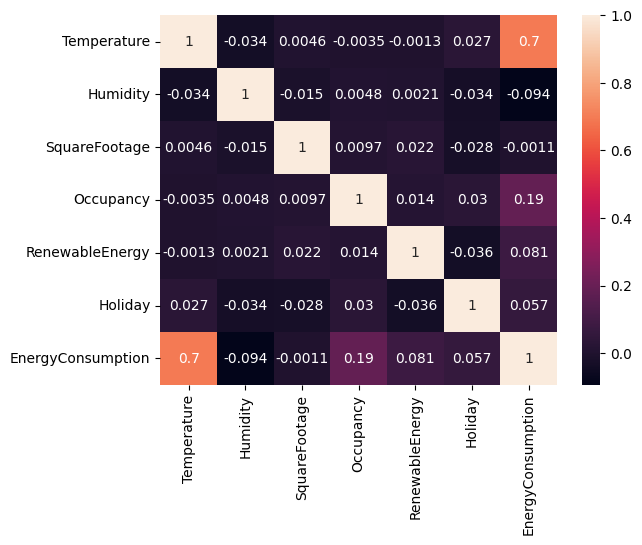

In [17]:
correlated = data.corr(numeric_only = True)
sns.heatmap(data = correlated,annot = True)

In [25]:
y = data["EnergyConsumption"]
x = data[["Humidity","SquareFootage","Occupancy","RenewableEnergy","Holiday"]]

In [26]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = .2,random_state = 42)

## Gradient Boosting

In [58]:
xg = XGBRegressor(n_estimators = 1000)
xg.fit(x_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

In [59]:
xg_train_pred = xg.predict(x_train)
xg_train_r2 = r2_score(y_train,xg_train_pred)
xg_train_mse = mean_squared_error(y_train,xg_train_pred)

In [60]:
xg_train_r2

0.9999998904593429

In [61]:
xg_train_mse

7.278987865035841e-06

In [62]:
xg_test_pred = xg.predict(x_test)
xg_test_r2 = r2_score(y_test,xg_test_pred)
xg_test_mse = mean_squared_error(y_test,xg_test_pred)

In [63]:
xg_test_r2

-0.4367591860508979

In [64]:
xg_test_mse

94.10754786285568

## Gradient Boosting Regressor

In [70]:
grad = GradientBoostingRegressor(learning_rate = 0.1,n_estimators = 100)
grad.fit(x_train,y_train)

GradientBoostingRegressor()

In [71]:
grad_train_pred = grad.predict(x_train)
grad_train_r2 = r2_score(y_train,grad_train_pred)
grad_train_mse = mean_squared_error(y_train,grad_train_pred)

In [72]:
grad_test_pred = grad.predict(x_test)
grad_test_r2 = r2_score(y_test,grad_test_pred)
grad_test_mse = mean_squared_error(y_test,grad_test_pred)

In [74]:
xg_test_r2

-0.4367591860508979

In [73]:
xg_test_mse

94.10754786285568